In [32]:
import pickle 
import numpy as np 
import matplotlib.pyplot as plt 
from matplotlib import animation
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from IPython.display import HTML
from pathlib import Path 

In [31]:
with open("/home/wuhlmann/BA/data/processed_data/cell_states/q_pred_landcover_0903_135428_cell_states_435_mds.p", "rb") as f:
		mds_435_dict = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/cell_states/q_pred_landcover_0903_135428_cell_states_802_mds.p", "rb") as f:
		mds_802_dict = pickle.load(f)

with open("/home/wuhlmann/BA/data/processed_data/cell_states/q_pred_landcover_0903_135428_cell_states_657_mds.p", "rb") as f:
		mds_657_dict = pickle.load(f)
		
with open("/home/wuhlmann/BA/data/processed_data/cell_states/q_pred_landcover_0903_135428_cell_states_39_mds.p", "rb") as f:
		mds_39_dict = pickle.load(f)

In [38]:
basin_mds_list = [mds_657_dict, mds_39_dict, mds_802_dict, mds_435_dict]

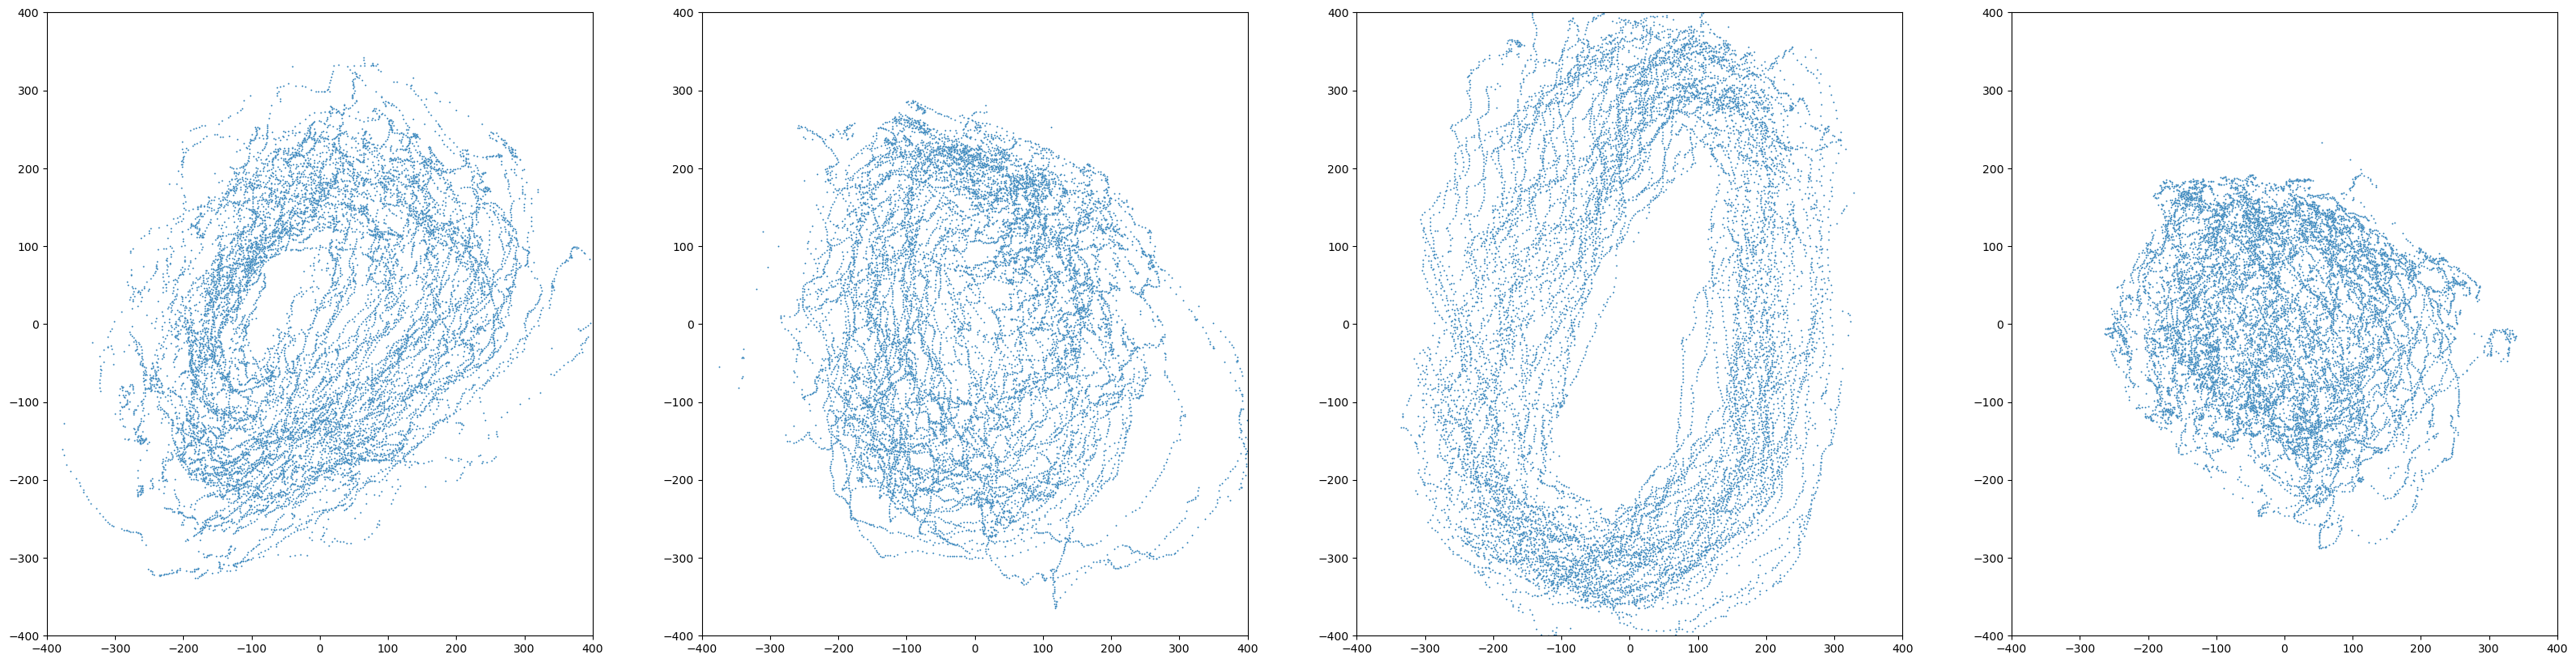

In [ ]:
fig, axs = plt.subplots(1,4, figsize=(40,10))

for i, mds_dict in enumerate(basin_mds_list): 
    
	mds_array = mds_dict[2].embedding_

	sns.scatterplot(x=mds_array[:,0],y=mds_array[:,1], s=2, ax=axs[i])
	axs[i].set_xlim([-400,400])
	axs[i].set_ylim([-400,400])

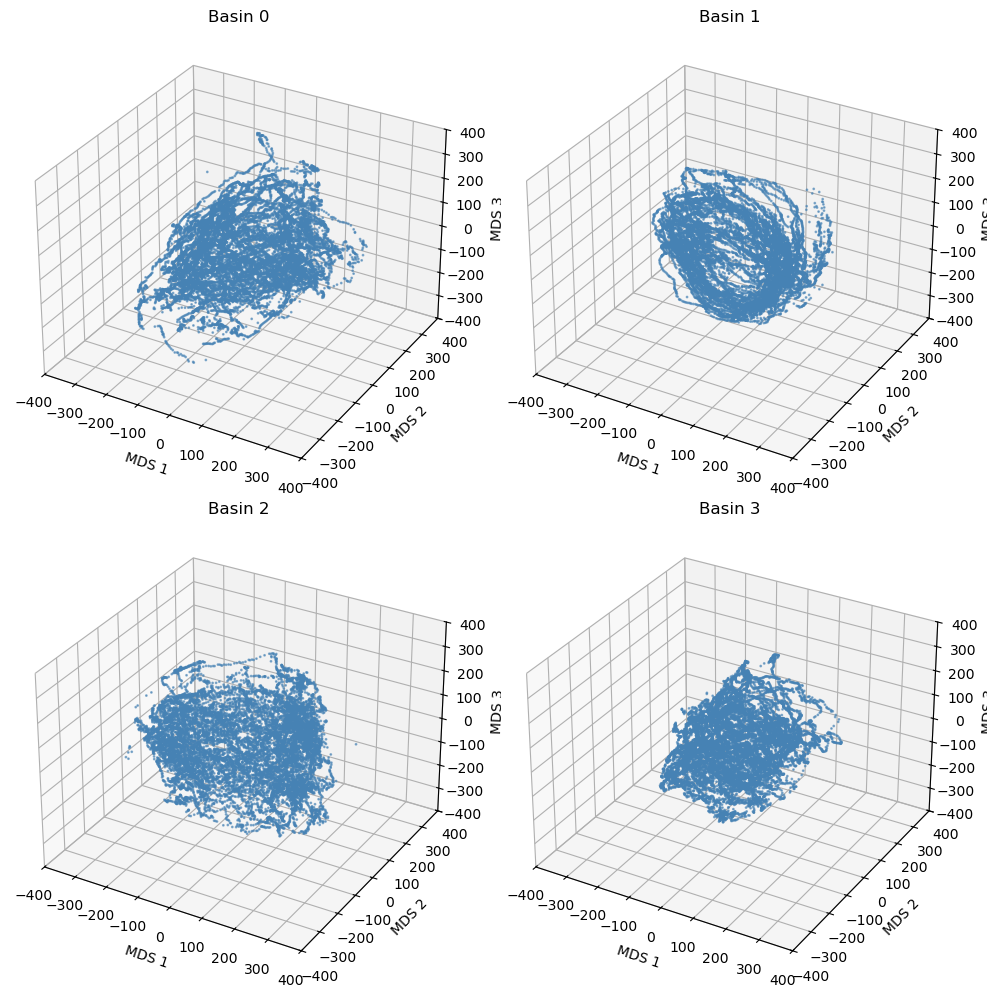

In [50]:
import matplotlib.pyplot as plt
import math

n = len(basin_mds_list)
ncols = math.ceil(math.sqrt(n))
nrows = math.ceil(n / ncols)

fig = plt.figure(figsize=(5 * ncols, 5 * nrows))

for i, mds_dict in enumerate(basin_mds_list):
    ax = fig.add_subplot(nrows, ncols, i + 1, projection='3d')
    mds_array = mds_dict[3].embedding_

    ax.scatter(
        mds_array[:, 0],
        mds_array[:, 1],
        mds_array[:, 2],
        s=1,
        color='steelblue',
        alpha=0.6
    )

    ax.set_xlim([-400, 400])
    ax.set_ylim([-400, 400])
    ax.set_zlim([-400, 400])
    ax.set_xlabel('MDS 1')
    ax.set_ylabel('MDS 2')
    ax.set_zlabel('MDS 3')
    ax.set_title(f'Basin {i}')

plt.tight_layout()
plt.show()

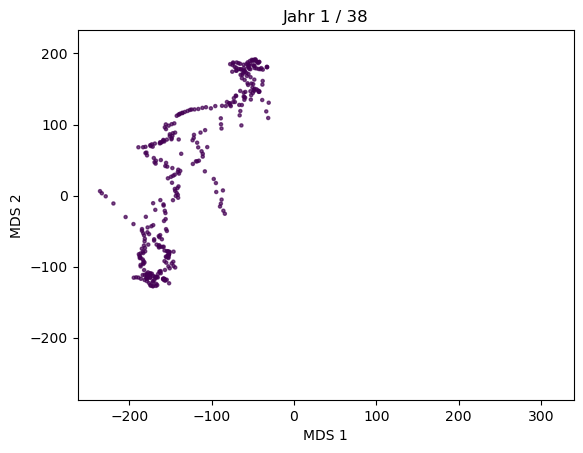

In [53]:
#2D 
mds_array = mds_435_dict[2].embedding_

fig, ax = plt.subplots()                          # ← kein projection='3d'

n_years = len(mds_array) // 365
colors = plt.cm.viridis(np.linspace(0, 1, n_years))
years = [mds_array[i*365:(i+1)*365] for i in range(n_years)]

ax.set_xlim(mds_array[:,0].min(), mds_array[:,0].max())
ax.set_ylim(mds_array[:,1].min(), mds_array[:,1].max())
ax.set_xlabel('MDS 1')
ax.set_ylabel('MDS 2')
                                                  # ← kein set_zlim, set_zlabel, view_init

scat = ax.scatter([], [], s=5, alpha=0.7)         # ← kein z-Argument
title = ax.set_title('')

def update(frame):
    if frame < 2:
        year_window = list(range(0, frame+1))
    else:
        year_window = list(range(frame-1, frame+1))

    d = np.concatenate([years[i] for i in year_window], axis=0)

    scat.set_offsets(d[:, :2])                    # ← statt _offsets3d

    point_colors = np.concatenate([
        np.tile(colors[i], (len(years[i]), 1))
        for i in year_window
    ])
    scat.set_color(point_colors)

    title.set_text(f'Jahr {frame + 1} / {n_years}')
    return scat, title

ani = animation.FuncAnimation(
    fig=fig,
    func=update,
    frames=n_years,
    interval=200,
    repeat=True
)
HTML(ani.to_jshtml())

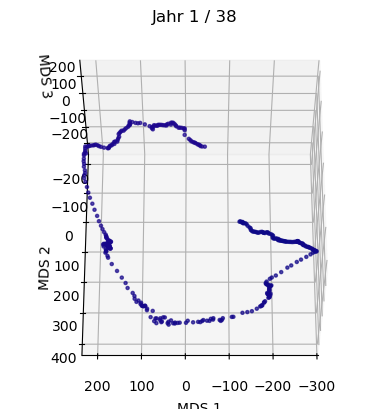

In [51]:
# 3D
mds_array = mds_39_dict[3].embedding_

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

n_years = len(mds_array) // 365
years = [mds_array[i*365:(i+1)*365] for i in range(n_years)]

# Durchgehende Farbrampe über alle Tage
global_indices = np.arange(len(mds_array))
norm = global_indices / len(mds_array)
all_colors = plt.cm.plasma(norm)
year_colors = [all_colors[i*365:(i+1)*365] for i in range(n_years)]

ax.set_xlim(mds_array[:,0].min(), mds_array[:,0].max())
ax.set_ylim(mds_array[:,1].min(), mds_array[:,1].max())
ax.set_zlim(mds_array[:,2].min(), mds_array[:,2].max())
ax.set_xlabel('MDS 1')
ax.set_ylabel('MDS 2')
ax.set_zlabel('MDS 3')
ax.view_init(azim=90, elev=60)

scat = ax.scatter([], [], [], s=5, alpha=0.7)
title = ax.set_title('')

def update(frame):
    if frame < 4:
        year_window = list(range(0, frame+1))
    else:
        year_window = list(range(frame-3, frame+1))

    d = np.concatenate([years[i]       for i in year_window], axis=0)
    c = np.concatenate([year_colors[i] for i in year_window], axis=0)

    scat._offsets3d = (d[:,0], d[:,1], d[:,2])
    scat.set_color(c)

    title.set_text(f'Jahr {frame + 1} / {n_years}')
    return scat, title

ani = animation.FuncAnimation(
    fig=fig,
    func=update,
    frames=n_years,
    interval=200,
    repeat=True
)
HTML(ani.to_jshtml())